# 📊 Frost Days — Statistiques descriptives & vérification qualité des données
Ce notebook vérifie la qualité des données météo Météo-France et la cohérence des résultats.

In [14]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_communes, load_stations, load_meteo_dept
from station_finder import find_nearest_stations
from frost_engine import compute_frost_days, get_monthly_summary, get_yearly_summary
from pipeline import run_frost_analysis

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Imports OK ✅')

Imports OK ✅


## 1. Chargement du référentiel des communes

In [15]:
communes = load_communes()
print(f'Nb communes : {len(communes):,}')
print(f'Colonnes    : {list(communes.columns)}')
print(f'Sans lat/lon: {communes[["lat","lon"]].isna().any(axis=1).sum():,}')
communes.head()

Nb communes : 0
Colonnes    : ['nom_commune', 'code_departement', 'lat', 'lon']
Sans lat/lon: 0


,nom_commune,code_departement,lat,lon


## 2. Chargement des stations météo

In [16]:
stations = load_stations()
print(f'Nb stations : {len(stations):,}')
stations.head()

Nb stations : 0


,station_id,lat,lon


## 3. Stations les plus proches d'une commune test

In [17]:
# Test : Grenoble (38)
TEST_COMMUNE = 'Grenoble'
TEST_DEPT    = '38'
TEST_LAT     = 45.1885
TEST_LON     = 5.7245

stations_dept = stations[stations['station_id'].str.startswith(TEST_DEPT.zfill(2))]
nearest = find_nearest_stations(TEST_LAT, TEST_LON, stations_dept, n=5, max_dist_km=100)
print(f'{len(nearest)} stations trouvées')
nearest

0 stations trouvées


,station_id,lat,lon,distance_km


## 4. Chargement des données météo — qualité

In [18]:
meteo = load_meteo_dept(TEST_DEPT, 2014, 2023)
print(f'Nb lignes    : {len(meteo):,}')
print(f'Colonnes     : {list(meteo.columns)}')
print(f'Période      : {meteo["date"].min()} → {meteo["date"].max()}')
print(f'Nb stations  : {meteo["station_id"].nunique()}')
print(f'% TN manquant: {meteo["tn"].isna().mean()*100:.1f}%')
meteo.describe()

Nb lignes    : 234,528
Colonnes     : ['station_id', 'date', 'tn']
Période      : 2014-01-01 00:00:00 → 2023-12-31 00:00:00
Nb stations  : 100
% TN manquant: 27.0%


,date,tn
count,234528,171156.000000
mean,2018-09-18 14:10:48.751535360,0.450063
min,2014-01-01 00:00:00,-2.430000
25%,2016-03-07 00:00:00,-0.070000
50%,2018-07-18 00:00:00,0.440000
75%,2021-02-22 00:00:00,1.000000
max,2023-12-31 00:00:00,2.530000
std,NaN,0.720438


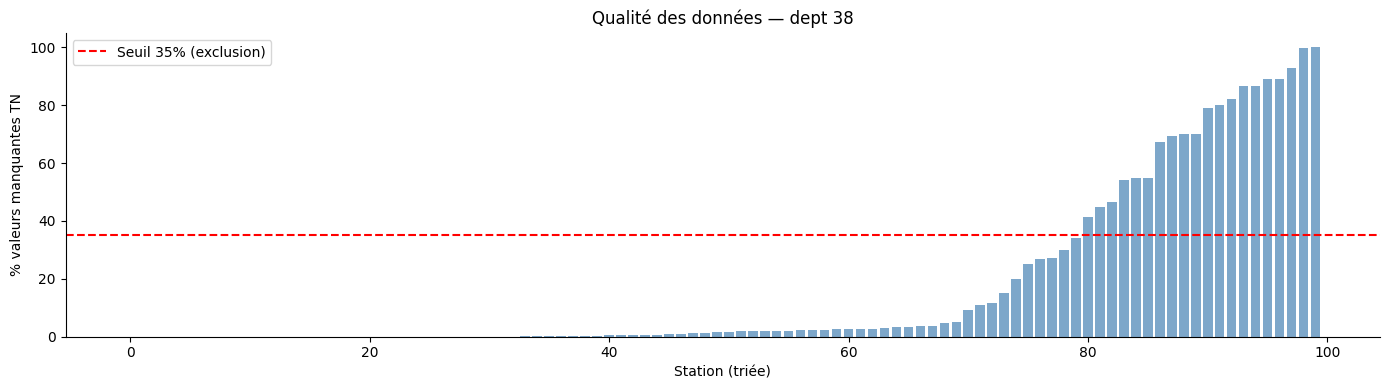

Stations exclues (>35% NaN) : 20/100


In [19]:
# Taux de valeurs manquantes par station
total_days = (pd.Timestamp('2023-12-31') - pd.Timestamp('2014-01-01')).days + 1
missing_by_station = (
    meteo.groupby('station_id')['tn']
    .apply(lambda x: x.isna().sum() / total_days * 100)
    .reset_index(name='missing_pct')
    .sort_values('missing_pct')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(missing_by_station)), missing_by_station['missing_pct'], color='steelblue', alpha=0.7)
ax.axhline(35, color='red', ls='--', label='Seuil 35% (exclusion)')
ax.set_xlabel('Station (triée)')
ax.set_ylabel('% valeurs manquantes TN')
ax.set_title(f'Qualité des données — dept {TEST_DEPT}')
ax.legend()
plt.tight_layout()
plt.show()

n_excl = (missing_by_station['missing_pct'] > 35).sum()
print(f'Stations exclues (>35% NaN) : {n_excl}/{len(missing_by_station)}')

## 5. Distribution des températures minimales

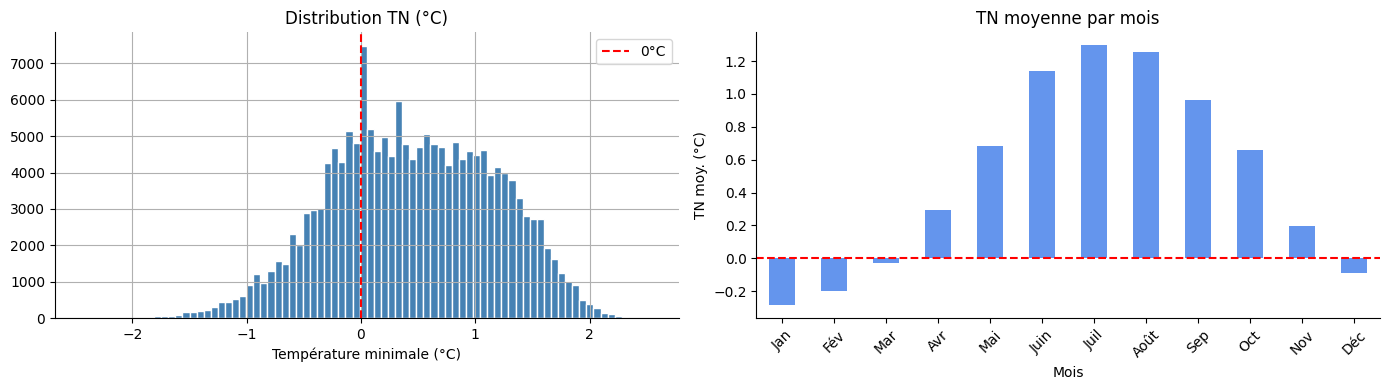

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

meteo['tn'].dropna().hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', ls='--', label='0°C')
axes[0].set_title('Distribution TN (°C)')
axes[0].set_xlabel('Température minimale (°C)')
axes[0].legend()

meteo['month'] = meteo['date'].dt.month
monthly_tn = meteo.groupby('month')['tn'].mean()
monthly_tn.plot(kind='bar', ax=axes[1], color='cornflowerblue')
axes[1].axhline(0, color='red', ls='--')
axes[1].set_title('TN moyenne par mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('TN moy. (°C)')
axes[1].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Août','Sep','Oct','Nov','Déc'], rotation=45)

plt.tight_layout()
plt.show()

## 6. Calcul frost days — Grenoble 2014–2023

In [21]:
results = run_frost_analysis(
    commune_name='Grenoble',
    dept_code='38',
    date_start='2014-01-01',
    date_end='2023-12-31',
)

print(f"Total jours de gel          : {results['total_frost_days']}")
print(f"Moyenne jours de gel / an   : {results['avg_frost_days_per_year']}")
print(f"Stations valides utilisées  : {results['n_valid_stations']}")

Total jours de gel          : 338
Moyenne jours de gel / an   : 33.8
Stations valides utilisées  : 2


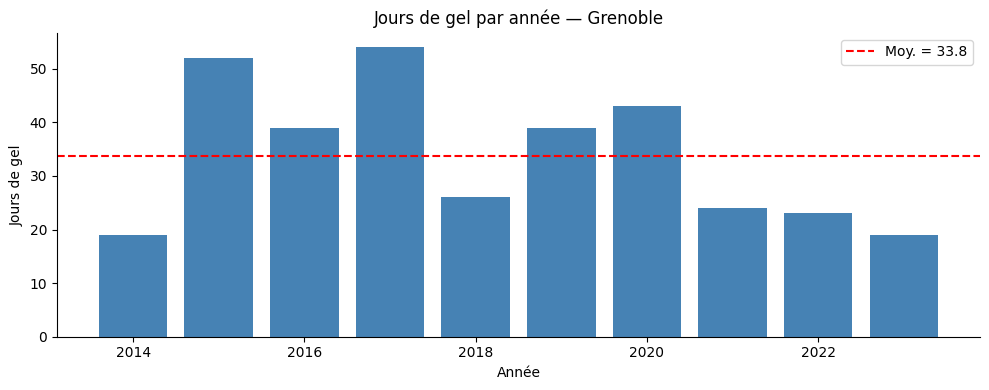

In [22]:
# Jours de gel par année
yearly = results['yearly_summary']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly['year'], yearly['frost_days'], color='steelblue')
ax.axhline(results['avg_frost_days_per_year'], color='red', ls='--', label=f"Moy. = {results['avg_frost_days_per_year']}")
ax.set_title('Jours de gel par année — Grenoble')
ax.set_xlabel('Année')
ax.set_ylabel('Jours de gel')
ax.legend()
plt.tight_layout()
plt.show()

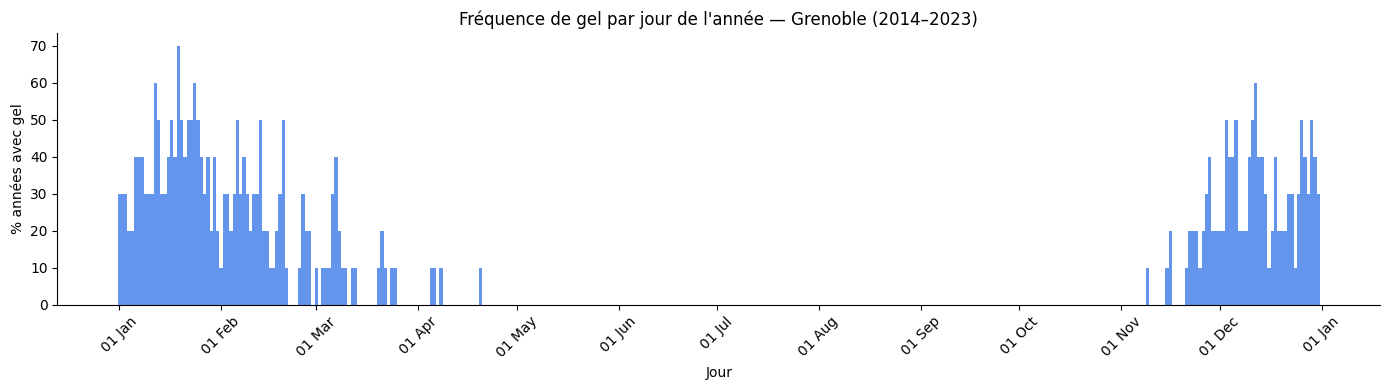

In [23]:
# Fréquence de gel par jour de l'année
bday = results['by_day_of_year'].copy()
bday['date_label'] = pd.to_datetime(
    '2000-' + bday['month'].astype(str).str.zfill(2) + '-' + bday['day'].astype(str).str.zfill(2),
    errors='coerce'
)
bday = bday.dropna(subset=['date_label']).sort_values('date_label')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(bday['date_label'], bday['frost_pct'], color='cornflowerblue', width=1)
ax.set_title('Fréquence de gel par jour de l\'année — Grenoble (2014–2023)')
ax.set_xlabel('Jour')
ax.set_ylabel('% années avec gel')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Top 10 jours les plus fréquemment gelés

In [24]:
MONTH_NAMES = {1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Juin',
               7:'Juil', 8:'Août', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'}
top10 = bday.sort_values('frost_pct', ascending=False).head(10).copy()
top10['Jour'] = top10['day'].astype(str) + ' ' + top10['month'].map(MONTH_NAMES)
top10 = top10.rename(columns={'frost_count': 'Nb années avec gel', 'frost_pct': 'Fréquence (%)'})
top10[['Jour', 'Nb années avec gel', 'Fréquence (%)']].reset_index(drop=True)

,Jour,Nb années avec gel,Fréquence (%)
0,19 Jan,7,70.0
1,24 Jan,6,60.0
2,12 Déc,6,60.0
3,12 Jan,6,60.0
4,26 Déc,5,50.0
5,6 Fév,5,50.0
6,13 Jan,5,50.0
7,20 Fév,5,50.0
8,25 Jan,5,50.0
9,23 Jan,5,50.0


## 8. Comparaison entre plusieurs communes

In [25]:
VILLES = [
    ('Grenoble', '38'),
    ('Lyon', '69'),
    ('Marseille', '13'),
    ('Paris', '75'),
]

comparatif = []
for ville, dept in VILLES:
    r = run_frost_analysis(ville, dept, '2014-01-01', '2023-12-31')
    if 'error' not in r:
        comparatif.append({
            'Commune': ville,
            'Département': dept,
            'Total jours de gel': r['total_frost_days'],
            'Moy. / an': r['avg_frost_days_per_year'],
            'Stations valides': r['n_valid_stations'],
        })

df_comp = pd.DataFrame(comparatif)
df_comp

,Commune,Département,Total jours de gel,Moy. / an,Stations valides
0,Grenoble,38,338,33.8,2
1,Marseille,13,0,0.0,0


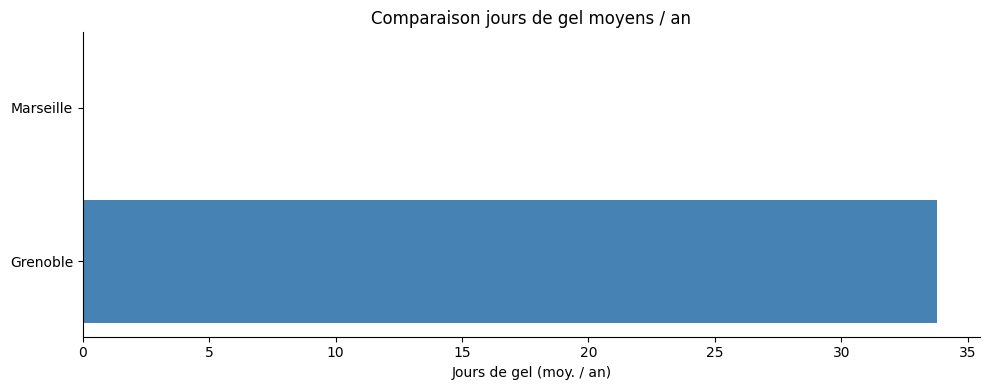

In [26]:
if not df_comp.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(df_comp['Commune'], df_comp['Moy. / an'], color='steelblue')
    ax.set_title('Comparaison jours de gel moyens / an')
    ax.set_xlabel('Jours de gel (moy. / an)')
    plt.tight_layout()
    plt.show()